Date Submitted 07/04/25

# Heart Disease Dataset
- Goal: Predict Presence of Heart Disease (Binary Classification Problem)
- 13 Features
- Methods Implemented:
  - K Nearest Neighbours (Classifier)
  - Decision Tree (Classifier)
  - Neural Network (MLPClassifier)
  - Support Vector Machine (SVM)

https://archive.ics.uci.edu/dataset/45/heart+disease

Evaluation Results of Each Method

| Algorithm                | Accuracy | Precision | Recall | F1-Score |
|--------------------------|----------|-----------|--------|----------|
| KNN                      | 0.85     | 0.87      | 0.85   | 0.85     |
| Decision Tree Classifier | 0.80     | 0.80      | 0.80   | 0.80     |
| Neural Network (MLP)     | 0.83     | 0.83      | 0.83   | 0.83     |
| SVM                      | 0.85     | 0.87      | 0.85   | 0.85     |

note: Precision, Recall & F1-Score use macro average from the Classification Report

---

### Data Loading & Preprocessing

Data is in .data format instead of .csv.

One way of getting around this is to load the data from the URL.

The following sources are used to help me with the logic:
- https://www.datacamp.com/tutorial/pandas-read-csv
- https://www.kaggle.com/code/nickbaynham/heart-disease/notebook

In [ ]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Rename Columns to Feuture Names
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"
]

data = pd.read_csv(url, names=columns)

In [ ]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
data.shape

(303, 14)

In [ ]:
# Check for missing data
data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Can see from data.info() that some columns are not of Dtype float64 or int64

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  num       303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [ ]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


Use the following sources here to help with pre-processing:
- To help with replacing ? with NaN
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.replace.html
- To help in dropping the rows with NaN
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html
- Convert all columns to numeric
https://pandas.pydata.org/docs/reference/api/pandas.to_numeric.html
- Transform the series
  https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.apply.html  
- Python lambda functions
  https://docs.python.org/3/tutorial/controlflow.html#lambda-expressions

In [ ]:
# Replace ? with NaN
data.replace('?', pd.NA, inplace=True)

In [ ]:
# Drop rows with NaN
data.dropna(inplace=True)

In [ ]:
# Convert all columns to numeric
data = data.apply(pd.to_numeric)

In [ ]:
# Check Dtype has been changed
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  num       297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 34.8 KB


- num has a value from 0-4
- This needs to be converted for binary classification problem
- We will use: 0 = no disease, 1 = disease

In [ ]:
# Convert num to binary:
data['num'] = data['num'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
# Checking counts of each
print(data['num'].value_counts())

num
0    160
1    137
Name: count, dtype: int64


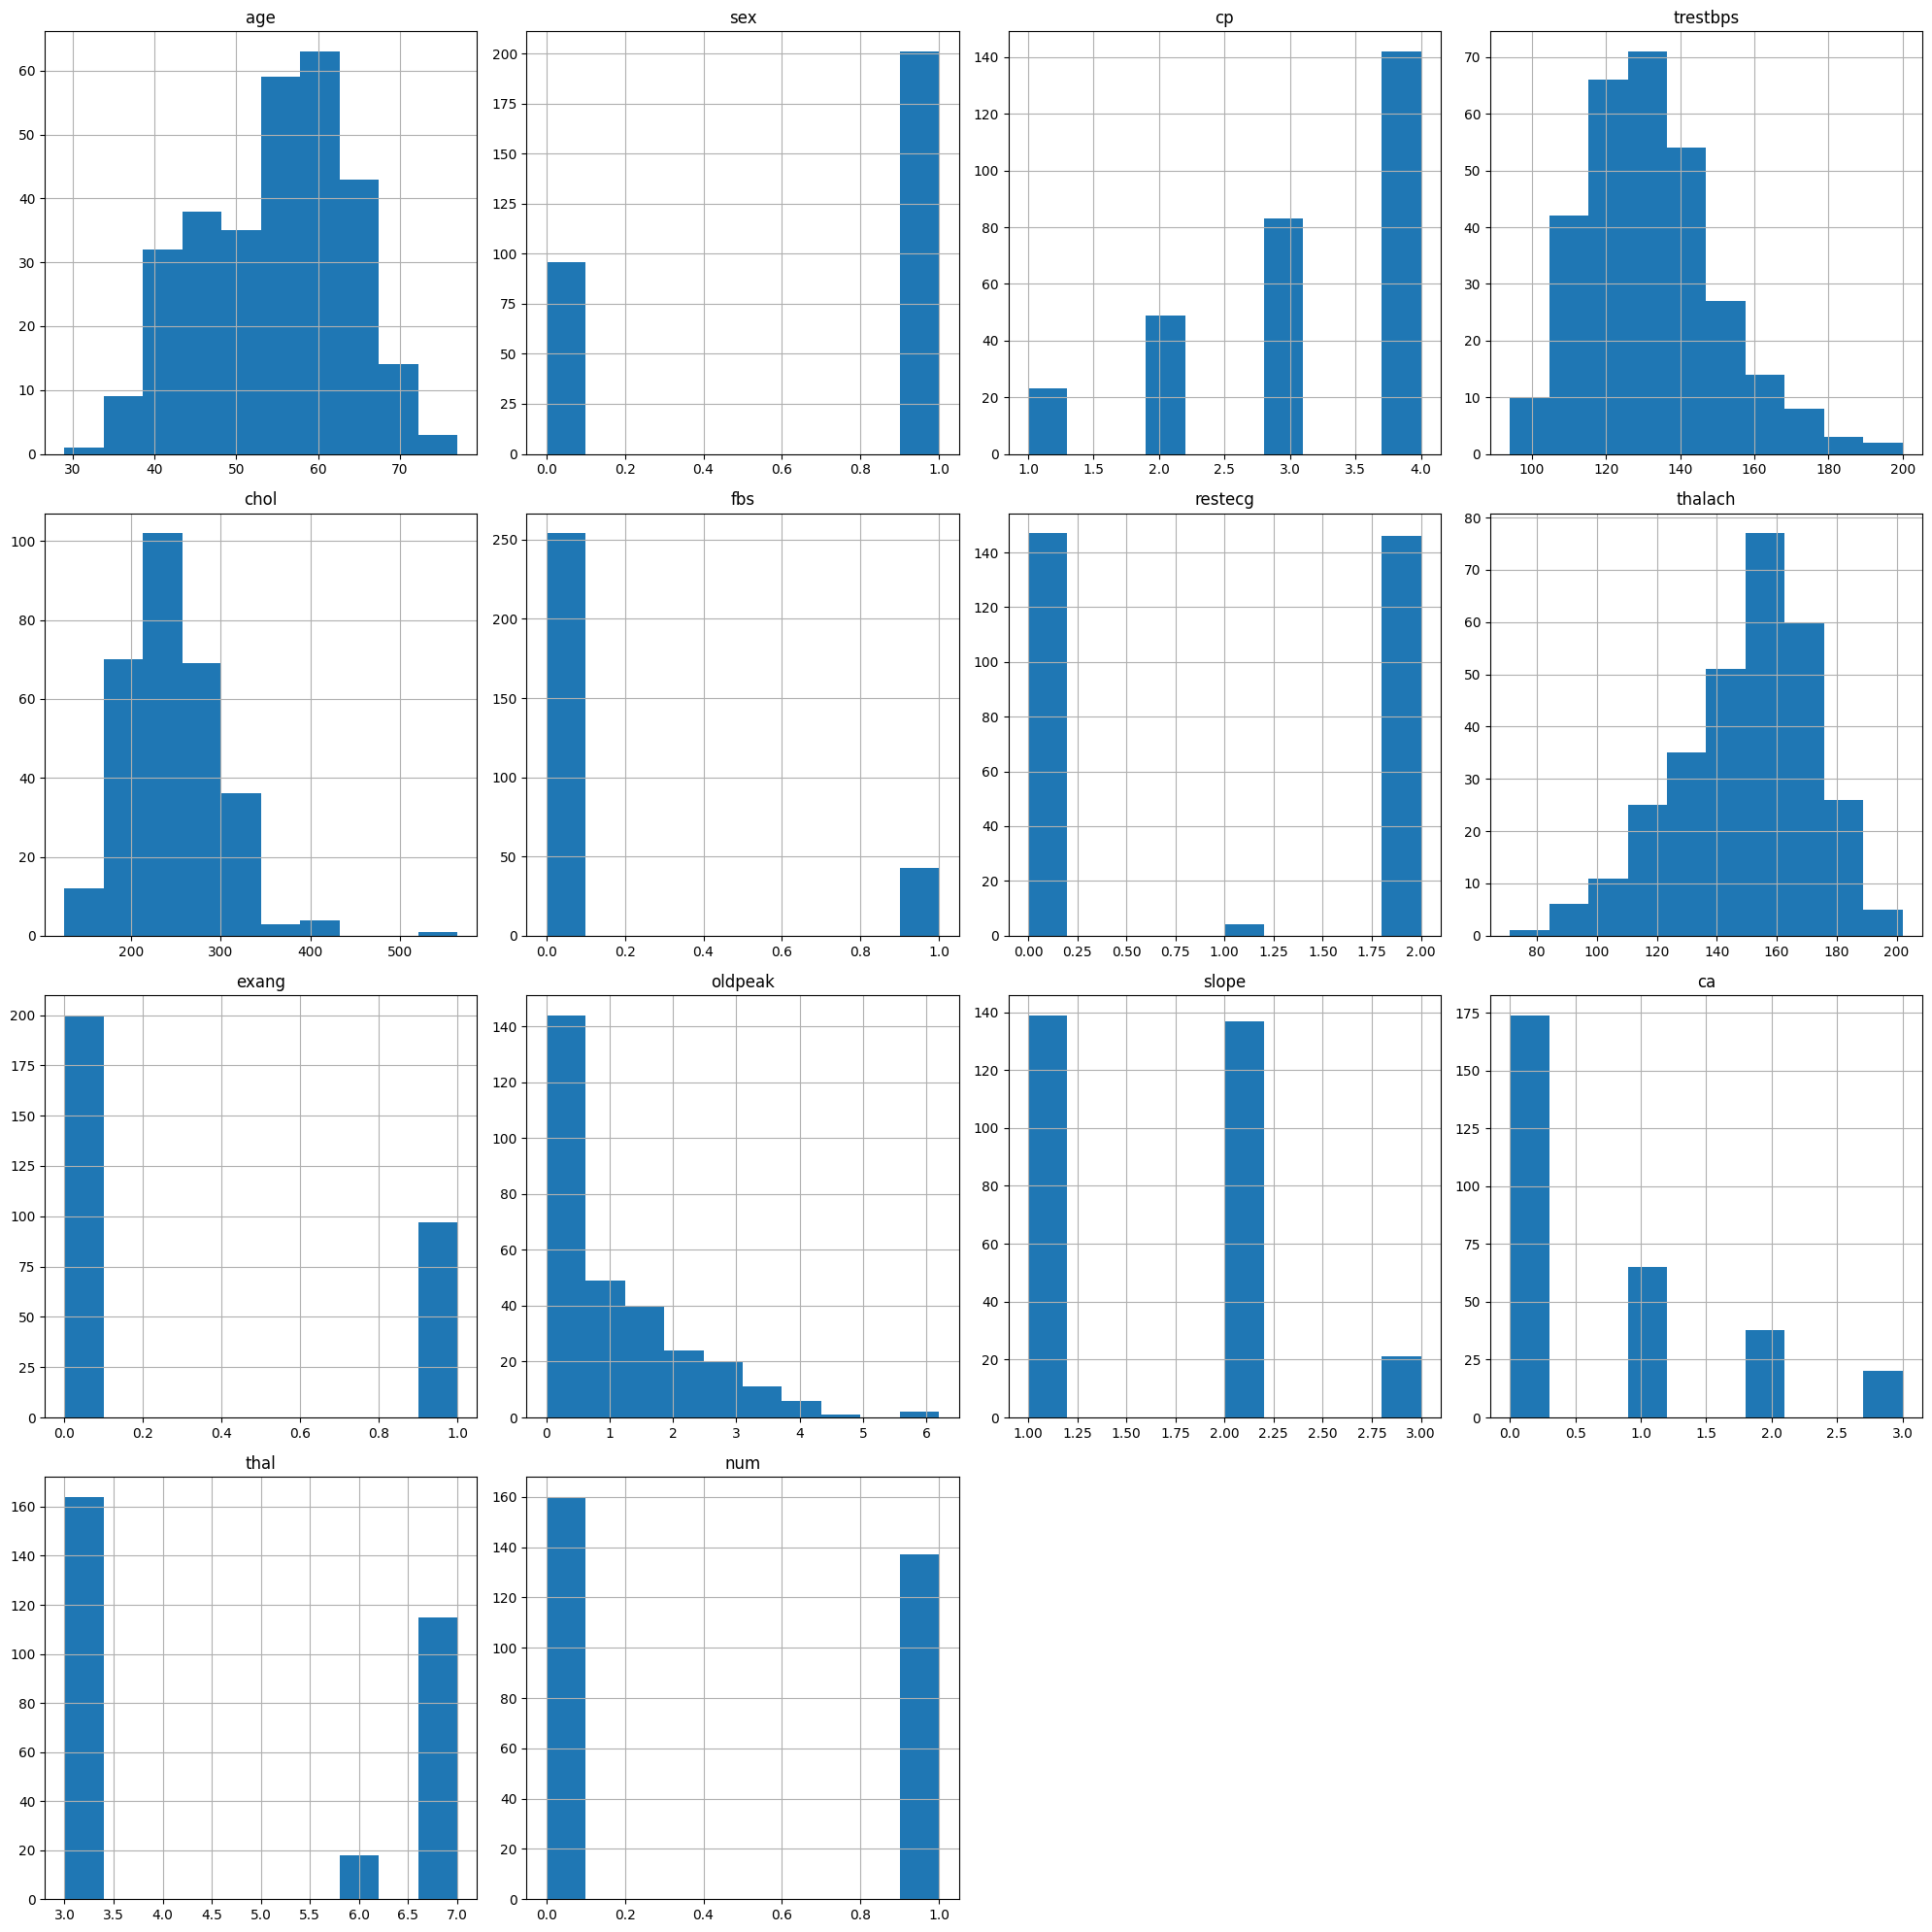

In [ ]:
import matplotlib.pyplot as plt

data.hist(figsize=(20,20))
plt.tight_layout()
plt.show()

In each histogram above, the x-axis represents Feature Values and the y-axis represents represents the Frequencies.

### Split Dataset

In [ ]:
# Dropping num from X, as this is our target
X = data.drop('num', axis=1)
y = data['num']

In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [ ]:
print("X_train Shape:\n", X_train.shape)
print("\ny_train Shape:\n", y_train.shape)

X_train Shape:
 (222, 13)

y_train Shape:
 (222,)


Using StandardScalar to scale Features.

The first dataset contained mainly categoric variables, which we encoded using LabelEncoder.

This dataset is entirely numeric and the Features vary in magnitudes, therefore scaling is important here.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Machine Learning Algorithms



### K-Nearest Neighbors (Classifier)

Finding best K value

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_scores = []

# finding best K value
for k in range(1, 41):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    score = knn.score(X_test_scaled, y_test)
    knn_scores.append(score)

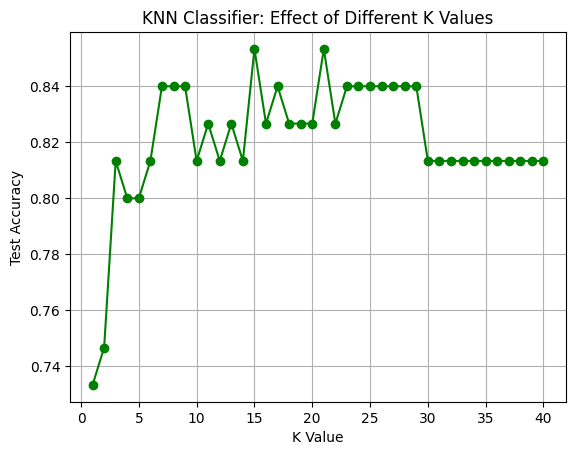

In [ ]:
# Display results graphically
import matplotlib.pyplot as plt

plt.plot(range(1, 41), knn_scores, color='green', marker='o')
plt.xlabel('K Value')
plt.ylabel('Test Accuracy')
plt.title('KNN Classifier: Effect of Different K Values')
plt.grid(True)
plt.show()

- Best K value appears to be 15

In [ ]:
# Train model with best_k value
best_k = 15
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

- Used the following documentation to help implement the Classification Report and Confusion Matrix:
  - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html
  - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate model using Classification Report + Confusion Matrix
print(f"KNN Final Results (k={best_k}):\n")
print("Accuracy:", knn.score(X_test_scaled, y_test))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

KNN Final Results (k=15):

Accuracy: 0.8533333333333334

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.95      0.87        39
           1       0.93      0.75      0.83        36

    accuracy                           0.85        75
   macro avg       0.87      0.85      0.85        75
weighted avg       0.87      0.85      0.85        75


Confusion Matrix:

[[37  2]
 [ 9 27]]


### Decision Tree (Classifier)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Finding best depth for Tree
depths = range(1, 16)
tree_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=0)
    tree.fit(X_train_scaled, y_train)
    score = tree.score(X_test_scaled, y_test)
    tree_scores.append(score)

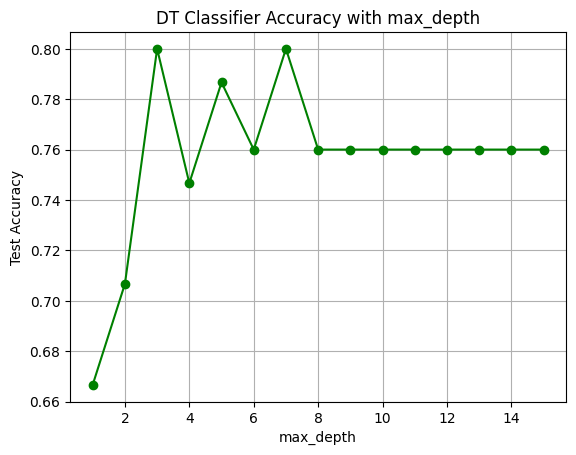

In [ ]:
# Display results graphically
plt.plot(depths, tree_scores, color='green', marker='o')
plt.xlabel('max_depth')
plt.ylabel('Test Accuracy')
plt.title('DT Classifier Accuracy with max_depth')
plt.grid(True)
plt.show()

- Best Depth appears to be 3

In [ ]:
# Train model with best_depth
best_depth = 3
tree = DecisionTreeClassifier(max_depth=best_depth, random_state=0)
tree.fit(X_train_scaled, y_train)
y_pred = tree.predict(X_test_scaled)

In [ ]:
# Evaluate model using Classification Report + Confusion Matrix
print(f"Decision Tree Final Results (max_depth={best_depth}):\n")
print("Accuracy:", tree.score(X_test_scaled, y_test))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Decision Tree Final Results (max_depth=3):

Accuracy: 0.8

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.77      0.80        39
           1       0.77      0.83      0.80        36

    accuracy                           0.80        75
   macro avg       0.80      0.80      0.80        75
weighted avg       0.80      0.80      0.80        75


Confusion Matrix:

[[30  9]
 [ 6 30]]


### Neural Network (MLPClassifier)

- solver='adam' used instead of solver='lbfgs' for smoother handling of larger datasets

In [ ]:
from sklearn.neural_network import MLPClassifier

# Find the best value for alpha
alphas = [0.00001, 0.0001, 0.001, 0.01, 0.1]
train_scores = []
test_scores = []

for alpha in alphas:
    mlp = MLPClassifier(hidden_layer_sizes=(100,), activation='relu',
                        solver='adam', alpha=alpha, max_iter=1000,
                        random_state=0)
    mlp.fit(X_train_scaled, y_train)
    train_scores.append(mlp.score(X_train_scaled, y_train))
    test_scores.append(mlp.score(X_test_scaled, y_test))

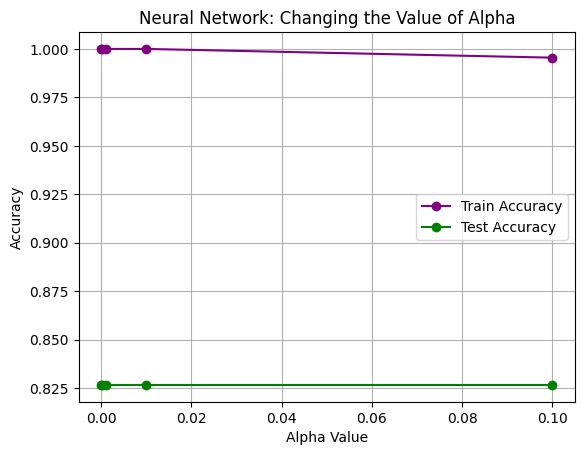

In [ ]:
# Display results graphically
plt.plot(alphas, train_scores, label='Train Accuracy', color='purple', marker='o')
plt.plot(alphas, test_scores, label='Test Accuracy', color='green', marker='o')
plt.xlabel('Alpha Value')
plt.ylabel('Accuracy')
plt.title('Neural Network: Changing the Value of Alpha')
plt.legend()
plt.grid(True)
plt.show()


- Tuning Alpha does not do much, so we will look at tuning hidden_layer_sizes

In [ ]:
# Find best config for hidden_layer_sizes
layer_sizes = [(50,), (100,), (50, 25), (100, 50), (100, 50, 25)]
train_scores = []
test_scores = []

for size in layer_sizes:
    mlp = MLPClassifier(hidden_layer_sizes=size, activation='relu',
                        solver='adam', alpha=0.0001,
                        max_iter=1000, random_state=0)
    mlp.fit(X_train_scaled, y_train)
    train_scores.append(mlp.score(X_train_scaled, y_train))
    test_scores.append(mlp.score(X_test_scaled, y_test))

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


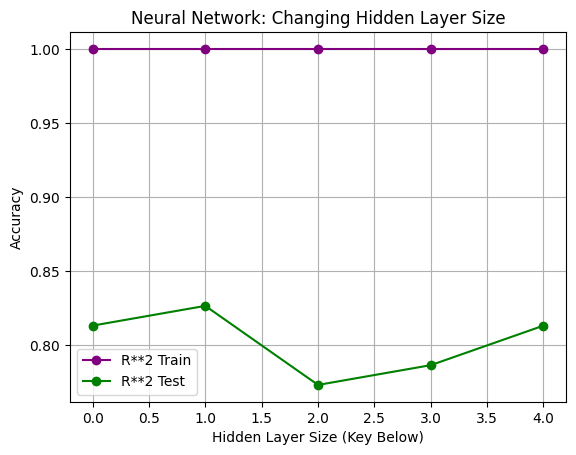

In [ ]:
# Display results graphically
x = range(len(layer_sizes))

plt.plot(x, train_scores, label='R**2 Train', color='purple', marker='o')
plt.plot(x, test_scores, label='R**2 Test', color='green', marker='o')
plt.xlabel('Hidden Layer Size (Key Below)')
plt.ylabel('Accuracy')
plt.title('Neural Network: Changing Hidden Layer Size')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("Key:")
i = 0.0
for size in layer_sizes:
  print(f"{i} = {size}")
  i += 1

Key:
0.0 = (50,)
1.0 = (100,)
2.0 = (50, 25)
3.0 = (100, 50)
4.0 = (100, 50, 25)


- (100,) looks to be the best value for hidden_layer_sizes

In [ ]:
# Train model with best hidden_layer_sizes
mlp = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam',
                    alpha=0.0001, max_iter=1000, random_state=0)

mlp.fit(X_train_scaled, y_train)

y_pred = mlp.predict(X_test_scaled)

In [ ]:
# Evaluate model using Classification Report + Confusion Matrix
print("Neural Network (MLPClassifier) Final Results:\n")
print("Accuracy:", mlp.score(X_test_scaled, y_test))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Neural Network (MLPClassifier) Final Results:

Accuracy: 0.8266666666666667

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.85      0.84        39
           1       0.83      0.81      0.82        36

    accuracy                           0.83        75
   macro avg       0.83      0.83      0.83        75
weighted avg       0.83      0.83      0.83        75


Confusion Matrix:

[[33  6]
 [ 7 29]]


### Support Vector Machine (SVC)

In [ ]:
from sklearn.svm import SVC

# Find best value for C
C_values = [0.01, 0.1, 1, 10, 100]
train_scores = []
test_scores = []

for c in C_values:
    svm = SVC(kernel='rbf', C=c, gamma='scale', random_state=0)
    svm.fit(X_train_scaled, y_train)
    train_scores.append(svm.score(X_train_scaled, y_train))
    test_scores.append(svm.score(X_test_scaled, y_test))

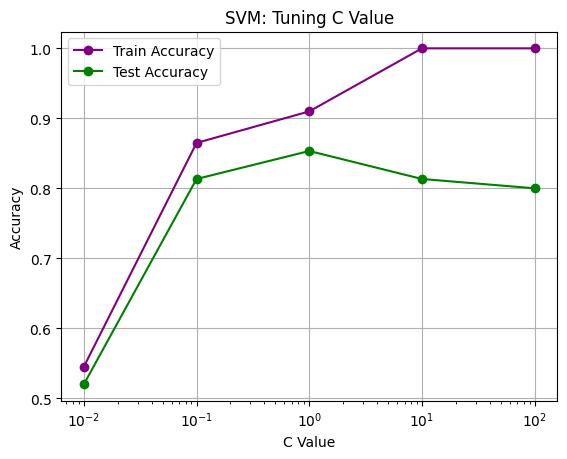

In [ ]:
# Display results graphically
plt.plot(C_values, train_scores, label='Train Accuracy', color='purple', marker='o')
plt.plot(C_values, test_scores, label='Test Accuracy', color='green', marker='o')
plt.xscale('log')
plt.xlabel('C Value')
plt.ylabel('Accuracy')
plt.title('SVM: Tuning C Value')
plt.legend()
plt.grid(True)
plt.show()


- Best value for C is 10**0 or 1.0

In [ ]:
# Find best value for gamma
gammas = ['scale', 0.001, 0.01, 0.1, 1, 10]
train_scores = []
test_scores = []

for g in gammas:
    svm = SVC(kernel='rbf', C=1.0, gamma=g, random_state=0)
    svm.fit(X_train_scaled, y_train)
    train_scores.append(svm.score(X_train_scaled, y_train))
    test_scores.append(svm.score(X_test_scaled, y_test))

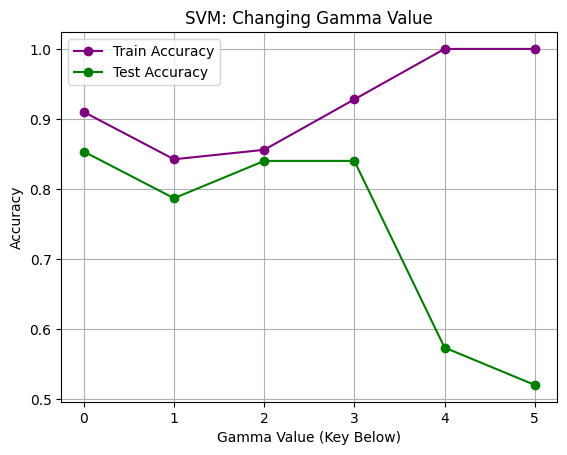

In [ ]:
x = range(len(gammas))

plt.plot(x, train_scores, label='Train Accuracy', color='purple', marker='o')
plt.plot(x, test_scores, label='Test Accuracy', color='green', marker='o')
plt.xlabel('Gamma Value (Key Below)')
plt.ylabel('Accuracy')
plt.title('SVM: Changing Gamma Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("Key:")
for i in range(len(gammas)):
    print(f"{i} = {gammas[i]}")

Key:
0 = scale
1 = 0.001
2 = 0.01
3 = 0.1
4 = 1
5 = 10


- 'scale' looks to be the best value for Gamma
- 1 / (n_features * X.var())
- https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

In [ ]:
# Train model with best C and gamma
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=0)
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)

In [ ]:
# Evaluate model using Classification Report + Confusion Matrix
print("SVM Final Results (C=1.0, gamma='scale'):\n")
print("Accuracy:", svm.score(X_test_scaled, y_test))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

SVM Final Results (C=1.0, gamma='scale'):

Accuracy: 0.8533333333333334

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.95      0.87        39
           1       0.93      0.75      0.83        36

    accuracy                           0.85        75
   macro avg       0.87      0.85      0.85        75
weighted avg       0.87      0.85      0.85        75


Confusion Matrix:

[[37  2]
 [ 9 27]]
